In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [222]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

In [ ]:
# DATA QUALITY CHECKS

print("Dataset Shapes:")
for name, df in {
    "orders": orders,
    "items": items,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "customers": customers,
    "payments": payments,
    "geolocation": geolocation,
    "translation": translation
}.items():
    print(f"{name:15s}: {df.shape}")

print("\nDuplicate Primary-Key Checks:")
print("Duplicate order_id:", orders["order_id"].duplicated().sum())
print("Duplicate customer_id:", customers["customer_id"].duplicated().sum())
print("Duplicate product_id:", products["product_id"].duplicated().sum())
print("Duplicate seller_id:", sellers["seller_id"].duplicated().sum())

print("\nOrder Status Distribution:")
print(orders["order_status"].value_counts(dropna=False))

Dataset Shapes:
orders         : (99441, 8)
items          : (112650, 7)
reviews        : (99224, 7)
products       : (32951, 9)
sellers        : (3095, 4)
customers      : (99441, 5)
payments       : (103886, 5)
geolocation    : (1000163, 5)
translation    : (71, 2)

Duplicate Primary-Key Checks:
Duplicate order_id: 0
Duplicate customer_id: 0
Duplicate product_id: 0
Duplicate seller_id: 0

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [224]:
dfs=[orders, items, reviews, products, sellers, customers, payments, geolocation, translation]
common_in_all = list(set.intersection(*[set(df.columns) for df in dfs]))
print(" The common columns in the 9 tables together: ")
print(list(common_in_all))

 The common columns in the 9 tables together: 
[]


In [225]:
from collections import Counter

# Count the occurrences of each column across all DataFrames
all_columns = []
for df in dfs:
    all_columns.extend(df.columns)

column_counts = Counter(all_columns)

# Create a summary DataFrame to display the counts
summary_df = (
    pd.DataFrame(column_counts.items(), columns=["Column Name", "Number of Tables Mentioned In"])
    .sort_values(by="Number of Tables Mentioned In", ascending=False)
    .reset_index(drop=True)
)

print(summary_df)

                      Column Name  Number of Tables Mentioned In
0                        order_id                              4
1                     customer_id                              2
2           product_category_name                              2
3                      product_id                              2
4                       seller_id                              2
5                  customer_state                              1
6                product_width_cm                              1
7          seller_zip_code_prefix                              1
8                     seller_city                              1
9                    seller_state                              1
10             customer_unique_id                              1
11       customer_zip_code_prefix                              1
12                  customer_city                              1
13             payment_sequential                              1
14              product_l

In [226]:
# Filter the summary DataFrame to show only columns that appear in more than one table
summary_df = summary_df[
    summary_df["Number of Tables Mentioned In"] > 1
].reset_index(drop=True)

print(summary_df)

             Column Name  Number of Tables Mentioned In
0               order_id                              4
1            customer_id                              2
2  product_category_name                              2
3             product_id                              2
4              seller_id                              2


In [227]:
dfs_dict = {
    "orders": orders,
    "items": items,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "customers": customers,
    "payments": payments,
    "geolocation": geolocation,
    "translation": translation,
}

# 2. quickly find which tables contain each column
col_to_tables = {}
for table_name, df in dfs_dict.items():
  for col in df.columns:
    if col not in col_to_tables:
      col_to_tables[col] = []
    col_to_tables[col].append(table_name)

# 3. Filter to keep only columns that are shared across multiple tables
shared_cols = {
    col: tables for col, tables in col_to_tables.items() if len(tables) > 1
}

# display the results in two different ways
# 1- simple list of shared columns and their associated tables
print("=== 1. Details of Shared Columns and Their Associated Tables ===")
for col, tables in shared_cols.items():
  print(f" Column [{col}] found in {len(tables)} tables: {', '.join(tables)}")

# 2- create a matrix to visualize the shared columns and their associated tables
matrix_data = []
for col, tables in shared_cols.items():
  row = {"Column Name": col, "Number of Tables": len(tables)}
  for table_name in dfs_dict.keys():
    row[table_name] = "✓" if table_name in tables else "-"
  matrix_data.append(row)

# show the matrix in a DataFrame format for better visualization
matrix_df = pd.DataFrame(matrix_data).sort_values(
    by="Number of Tables", ascending=False
)

print("\n=== 2. Matrix of Shared Columns and Tables ===")
print(matrix_df.to_string(index=False))

=== 1. Details of Shared Columns and Their Associated Tables ===
 Column [order_id] found in 4 tables: orders, items, reviews, payments
 Column [customer_id] found in 2 tables: orders, customers
 Column [product_id] found in 2 tables: items, products
 Column [seller_id] found in 2 tables: items, sellers
 Column [product_category_name] found in 2 tables: products, translation

=== 2. Matrix of Shared Columns and Tables ===
          Column Name  Number of Tables orders items reviews products sellers customers payments geolocation translation
             order_id                 4      ✓     ✓       ✓        -       -         -        ✓           -           -
          customer_id                 2      ✓     -       -        -       -         ✓        -           -           -
           product_id                 2      -     ✓       -        ✓       -         -        -           -           -
            seller_id                 2      -     ✓       -        -       ✓         -   

In [ ]:
# Convert date columns
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
  orders[col] = pd.to_datetime(orders[col])

#Row Explosion
payments_sum = (
    payments.groupby("order_id")["payment_value"].sum().reset_index()
)
reviews_avg = reviews.groupby("order_id")["review_score"].mean().reset_index()

#  1order_level
order_level = orders.merge(customers, on="customer_id", how="left")
order_level = order_level.merge(payments_sum, on="order_id", how="left")
order_level = order_level.merge(reviews_avg, on="order_id", how="left")

# (Delivered Orders)
order_level = order_level[order_level["order_status"] == "delivered"].copy()
order_level["delivery_days"] = (
    order_level["order_delivered_customer_date"]
    - order_level["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)
order_level["is_delayed"] = (
    order_level["order_delivered_customer_date"]
    > order_level["order_estimated_delivery_date"]
)
order_level["purchase_month"] = order_level[
    "order_purchase_timestamp"
].dt.to_period("M")

# (Item-Level Data)
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(items, on="order_id", how="inner")
df = df.merge(payments_sum, on="order_id", how="left")
df = df.merge(reviews_avg, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(translation, on="product_category_name", how="left")

# (Delivered Items)
delivered = df[df["order_status"] == "delivered"].copy()

delivered["item_revenue"] = delivered["price"] + delivered["freight_value"]
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)
delivered["is_delayed"] = (
    delivered["order_delivered_customer_date"]
    > delivered["order_estimated_delivery_date"]
)
delivered["is_intrastate"] = (
    delivered["customer_state"] == delivered["seller_state"]
)

print("--- Data Preprocessing Completed ---")
print(f"Total Unique Delivered Orders (order_level): {len(order_level):,}")
print(f"Total Clean Delivered Items (delivered): {len(delivered):,}")

--- Data Preprocessing Completed ---
Total Unique Delivered Orders (order_level): 96,478
Total Clean Delivered Items (delivered): 110,197


In [ ]:
# ORDER-LEVEL VALIDATION

print("Order-level rows:", len(order_level))
print("Unique order_ids:", order_level["order_id"].nunique())

assert len(order_level) == order_level["order_id"].nunique()

print("\nMissing values in key order-level metrics:")
print(
    order_level[
        [
            "payment_value",
            "delivery_days",
            "is_delayed",
            "review_score"
        ]
    ].isna().sum()
)

Order-level rows: 96478
Unique order_ids: 96478

Missing values in key order-level metrics:
payment_value      1
delivery_days      8
is_delayed         0
review_score     646
dtype: int64


In [230]:
financial_orders = order_level.dropna(
    subset=["payment_value"]
).copy()

print(
    f"Orders included in financial analysis: "
    f"{len(financial_orders):,}"
)

Orders included in financial analysis: 96,477


In [231]:
total_sales = financial_orders["payment_value"].sum()
aov = financial_orders["payment_value"].mean()

## 1. FINANCIAL PERFORMANCE & PURCHASING BEHAVIOR

In [ ]:
total_sales = order_level["payment_value"].sum()
aov = order_level["payment_value"].mean()

print(f"Total Platform Sales (Corrected): {total_sales:,.2f} BRL")
print(f"Average Order Value (AOV): {aov:,.2f} BRL\n")

Total Platform Sales (Corrected): 15,422,461.77 BRL
Average Order Value (AOV): 159.86 BRL




--- Monthly Sales Trend (Order-Level Corrected) ---
purchase_month  payment_value
       2016-09           0.00
       2016-10       46566.71
       2016-12          19.62
       2017-01      127545.67
       2017-02      271298.65
       2017-03      414369.39
       2017-04      390952.18
       2017-05      567066.73
       2017-06      490225.60
       2017-07      566403.93


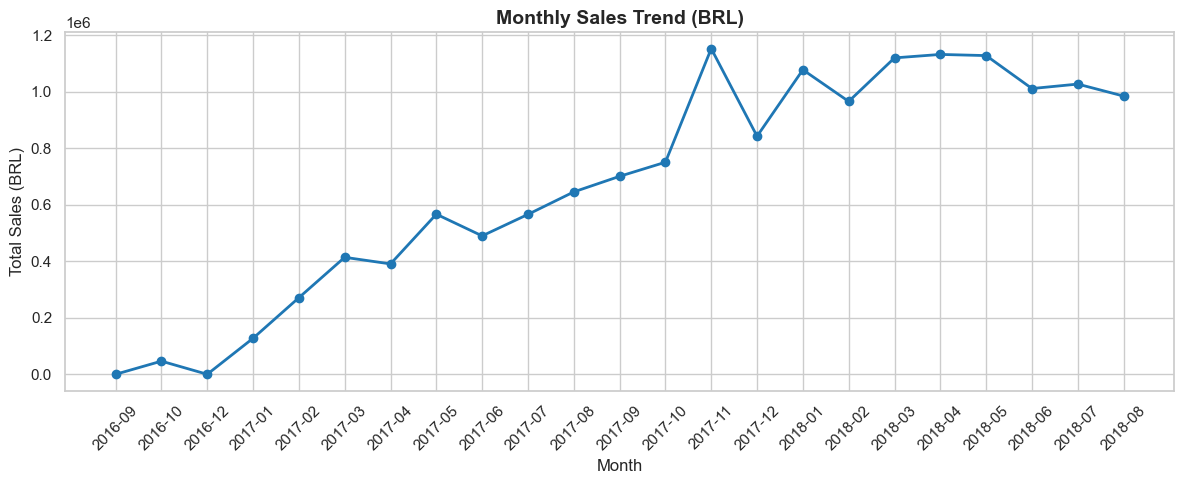

In [ ]:
monthly_sales = (
    order_level.groupby("purchase_month")["payment_value"].sum().reset_index()
)

print("\n--- Monthly Sales Trend (Order-Level Corrected) ---")
print(monthly_sales.head(10).to_string(index=False))

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["purchase_month"].astype(str),
    monthly_sales["payment_value"],
    marker="o",
    color="#1f77b4",
    linewidth=2,
)
plt.title("Monthly Sales Trend (BRL)", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales (BRL)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [234]:
prod_performance = delivered.groupby("product_category_name_english").agg(
    total_items=("order_id", "count"),
    unique_orders=("order_id", "nunique"),
    avg_delay_rate=("is_delayed", lambda x: x.mean() * 100),
    avg_rating=("review_score", "mean"),
)

print("\n--- Top Product Categories Performance ---")
print(
    prod_performance.sort_values(by="total_items", ascending=False).head(10)
)


--- Top Product Categories Performance ---
                               total_items  unique_orders  avg_delay_rate  \
product_category_name_english                                               
bed_bath_table                       10953           9272        8.399525   
health_beauty                         9465           8647        9.054411   
sports_leisure                        8431           7530        7.413118   
furniture_decor                       8160           6307        8.431373   
computers_accessories                 7644           6530        7.770801   
housewares                            6795           5743        6.490066   
watches_gifts                         5859           5495        8.277863   
telephony                             4430           4093        8.329571   
garden_tools                          4268           3448        7.966261   
auto                                  4140           3810        8.285024   

                               

In [ ]:
# PAYMENT METHODS & INSTALLMENTS

order_payment = (
    payments.groupby(["order_id", "payment_type"])
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

payment_stats = (
    order_payment.groupby("payment_type")
    .agg(
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean"),
        total_transactions=("order_id", "count"),
        total_payment_amount=("payment_value", "sum")
    )
    .reset_index()
    .sort_values(by="total_payment_amount", ascending=False)
)

print("\n--- Payment Methods & Installments Analysis ---")
print(payment_stats.round(2).to_string(index=False))


--- Payment Methods & Installments Analysis ---
payment_type  avg_payment_value  avg_installments  total_transactions  total_payment_amount
 credit_card             163.94              3.51               76505           12542084.19
      boleto             145.03              1.00               19784            2869361.27
     voucher              98.15              1.00                3866             379436.87
  debit_card             142.66              1.00                1528             217989.79
 not_defined               0.00              1.00                   3                  0.00


## 2. GEOGRAPHIC DISTRIBUTION & SUPPLY CHAIN DYNAMICS

In [236]:
state_orders = order_level["customer_state"].value_counts(normalize=True) * 100

print("--- Top 5 States by Total Orders (%) ---")
print(state_orders.head(5))

--- Top 5 States by Total Orders (%) ---
customer_state
SP    41.979519
RJ    12.800846
MG    11.768486
RS     5.540123
PR     5.102718
Name: proportion, dtype: float64


In [ ]:
# DELIVERY PERFORMANCE BY CUSTOMER STATE

state_performance = (
    order_level.groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        delay_rate=("is_delayed", "mean")
    )
    .reset_index()
)

state_performance["delay_rate"] *= 100

# Avoid unstable percentages for very small states
state_performance_filtered = (
    state_performance[
        state_performance["total_orders"] >= 100
    ]
    .sort_values("delay_rate", ascending=False)
)

print("--- States with Highest Delivery Delay Rates ---")
print(
    state_performance_filtered
    .head(10)
    .round(2)
    .to_string(index=False)
)

--- States with Highest Delivery Delay Rates ---
customer_state  total_orders  avg_delivery_days  delay_rate
            AL           397              24.54       23.93
            MA           717              21.57       19.67
            PI           476              19.46       15.97
            CE          1279              21.27       15.32
            SE           335              21.52       15.22
            BA          3256              19.34       14.04
            RJ         12350              15.31       13.47
            TO           274              17.66       12.77
            PA           946              23.77       12.37
            ES          1995              15.79       12.23


In [ ]:
# INTRASTATE VS INTERSTATE SHIPPING

shipment_level = (
    delivered
    .groupby(["order_id", "seller_id"])
    .agg(
        customer_state=("customer_state", "first"),
        seller_state=("seller_state", "first"),
        delivery_days=("delivery_days", "first"),
        is_delayed=("is_delayed", "first")
    )
    .reset_index()
)

shipment_level["shipping_type"] = np.where(
    shipment_level["customer_state"] == shipment_level["seller_state"],
    "Intrastate",
    "Interstate"
)

shipping_comparison = (
    shipment_level.groupby("shipping_type")
    .agg(
        shipments=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        delay_rate=("is_delayed", "mean")
    )
    .reset_index()
)

shipping_comparison["delay_rate"] *= 100

print("--- Intrastate vs Interstate Shipping ---")
print(shipping_comparison.round(2).to_string(index=False))

--- Intrastate vs Interstate Shipping ---
shipping_type  shipments  avg_delivery_days  delay_rate
   Interstate      62633              15.09        9.16
   Intrastate      35186               7.92        5.99


## 3. SHIPPING DELAYS & IMPACT ON CUSTOMER SATISFACTION

In [ ]:
overall_avg_delivery = order_level['delivery_days'].mean()
overall_delay_rate = order_level['is_delayed'].mean() * 100

print(f"Overall Average Delivery Time: {overall_avg_delivery:.2f} Days")
print(f"Overall Delay Rate: {overall_delay_rate:.2f}%\n")

Overall Average Delivery Time: 12.56 Days
Overall Delay Rate: 8.11%



Rating Impact (On-time vs Delayed):
          Status  mean  count
On-time Delivery  4.29  88171
Delayed Delivery  2.57   7661


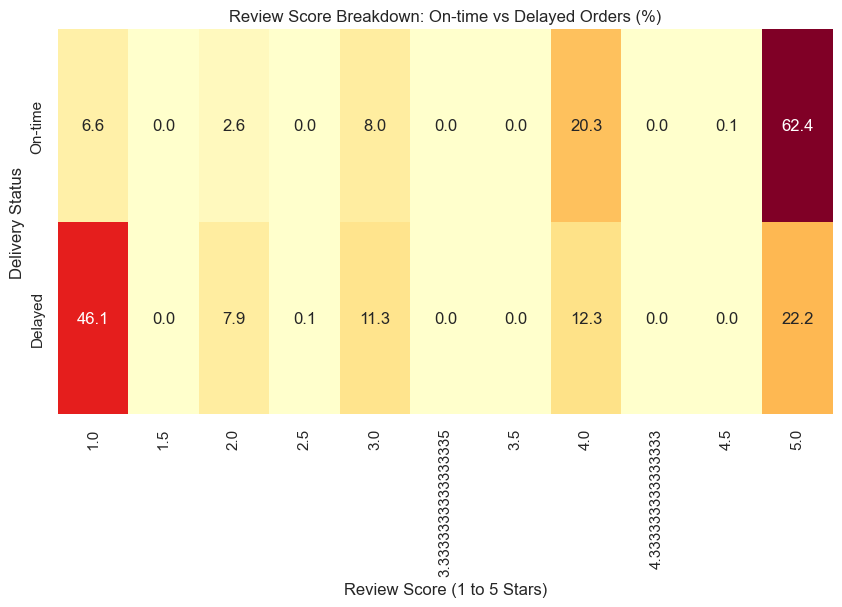

In [ ]:
rating_delay = order_level.groupby('is_delayed')['review_score'].agg(['mean', 'count']).reset_index()
rating_delay['Status'] = rating_delay['is_delayed'].map({False: 'On-time Delivery', True: 'Delayed Delivery'})
print("Rating Impact (On-time vs Delayed):")
print(rating_delay[['Status', 'mean', 'count']].round(2).to_string(index=False))

# (Cross-tabulation)
score_dist = pd.crosstab(order_level['is_delayed'], order_level['review_score'], normalize='index') * 100
score_dist.index = ['On-time', 'Delayed']

plt.figure(figsize=(10, 5))
sns.heatmap(score_dist, annot=True, fmt=".1f", cmap="YlOrRd", cbar=False)
plt.title('Review Score Breakdown: On-time vs Delayed Orders (%)')
plt.xlabel('Review Score (1 to 5 Stars)')
plt.ylabel('Delivery Status')
plt.show()

In [ ]:
# LOW REVIEW ANALYSIS

reviewed_orders = order_level.dropna(
    subset=["review_score"]
).copy()

low_reviews_pct = (
    reviewed_orders["review_score"].isin([1, 2]).mean()
) * 100

one_star_pct = (
    reviewed_orders["review_score"].eq(1).mean()
) * 100

print(
    f"Low Reviews (1 & 2 Stars) Share: "
    f"{low_reviews_pct:.2f}%"
)

print(
    f"1-Star Reviews Share Alone: "
    f"{one_star_pct:.2f}%"
)

Low Reviews (1 & 2 Stars) Share: 12.76%
1-Star Reviews Share Alone: 9.72%


## 4. SELLER PERFORMANCE & OPERATIONAL RISK

In [ ]:
# 5.(Seller Analysis)

seller_orders = (
    delivered.groupby(['seller_id', 'order_id'])
    .agg(
        review_score=('review_score', 'first'),
        is_delayed=('is_delayed', 'first'),
        seller_state=('seller_state', 'first'),
        seller_order_revenue=('item_revenue', 'sum')
    )
    .reset_index()
)

seller_summary = seller_orders.groupby('seller_id').agg(
    seller_state=('seller_state', 'first'),
    total_revenue=('seller_order_revenue', 'sum'),
    total_orders=('order_id', 'count'),
    avg_rating=('review_score', 'mean'),
    delay_rate=('is_delayed', lambda x: x.mean() * 100)
).reset_index()

print("\n--- Top 5 Sellers Summary ---")
print(seller_summary.sort_values(by='total_revenue', ascending=False).head().to_string(index=False))


--- Top 5 Sellers Summary ---
                       seller_id seller_state  total_revenue  total_orders  avg_rating  delay_rate
4869f7a5dfa277a7dca6462dcf3b52b2           SP      247007.06          1124    4.150538   11.565836
7c67e1448b00f6e969d365cea6b010ab           SP      237806.69           973    3.495863   10.071942
4a3ca9315b744ce9f8e9374361493884           SP      231220.43          1772    3.853109   11.004515
53243585a1d6dc2643021fd1853d8905           BA      230797.02           348    4.193642    4.310345
fa1c13f2614d7b5c4749cbc52fecda94           SP      200833.50           578    4.372822   10.207612


In [243]:
seller_by_state = seller_summary.groupby('seller_state').agg(
    seller_count=('seller_id', 'count'),
    avg_delay_rate=('delay_rate', 'mean'),
    avg_rating=('avg_rating', 'mean')
).query('seller_count > 10').sort_values(by='avg_delay_rate')

prod_performance = (
    delivered
    .groupby("product_category_name_english")
    .agg(
        total_items=("order_id", "count"),
        unique_orders=("order_id", "nunique"),
        avg_delay_rate=("is_delayed", lambda x: x.mean() * 100),
        avg_rating=("review_score", "mean")
    )
    .query("total_items >= 500")
    .sort_values(by="avg_delay_rate", ascending=False)
)

print("\nProduct Categories with Highest Delay Rates:")
print(
    prod_performance
    .head(5)
    .round(2)
    .to_string(index=False)
)


Product Categories with Highest Delay Rates:
 total_items  unique_orders  avg_delay_rate  avg_rating
        2729           2517            9.75        4.07
        9465           8647            9.05        4.19
        1668           1254            8.93        3.51
        2982           2809            8.79        4.08
         651            611            8.60        4.22


In [244]:
# ==========================================
# PRODUCT SIZE / WEIGHT VS DELIVERY DELAY
# ==========================================

product_dimensions = (
    delivered
    .groupby("product_id")
    .agg(
        avg_weight_g=("product_weight_g", "first"),
        avg_length_cm=("product_length_cm", "first"),
        avg_width_cm=("product_width_cm", "first"),
        avg_height_cm=("product_height_cm", "first"),
        avg_delay_rate=("is_delayed", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        total_items=("order_id", "count")
    )
    .reset_index()
)

product_dimensions["volume_cm3"] = (
    product_dimensions["avg_length_cm"]
    * product_dimensions["avg_width_cm"]
    * product_dimensions["avg_height_cm"]
)

product_dimensions["delay_rate_pct"] = (
    product_dimensions["avg_delay_rate"] * 100
)

print("--- Product Weight/Volume vs Delivery Performance ---")
print(
    product_dimensions[
        ["avg_weight_g", "volume_cm3", "delay_rate_pct", "avg_delivery_days", "total_items"]
    ].corr()["delay_rate_pct"]
)

--- Product Weight/Volume vs Delivery Performance ---
avg_weight_g         0.042226
volume_cm3           0.029457
delay_rate_pct       1.000000
avg_delivery_days    0.562577
total_items          0.002412
Name: delay_rate_pct, dtype: float64



--- Complaint Analysis Framework ---
Analysis Type: Keyword-based Complaint Analysis
Proposed Future Solution: Implement an End-to-End NLP-based Sentiment & Topic Classification Model.
Note: Complaint categories are non-mutually exclusive; a single review may contain multiple complaint themes.

--- Negative Reviews Breakdown (1 & 2 Stars) ---
    Complaint Type  Count  Percentage (%)
Delivery Complaint   2719           24.97
  Seller Complaint   1333           12.24
 Product Complaint    891            8.18
 Quality Complaint    736            6.76


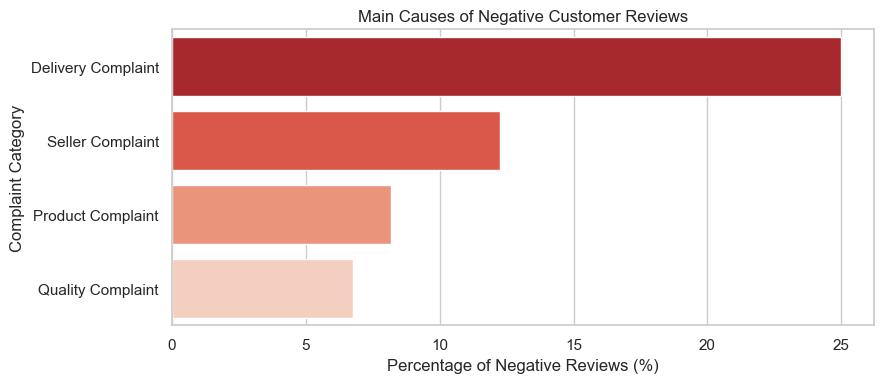

In [ ]:
# 7.(Reviews Analysis)

reviews_text = reviews[['order_id', 'review_score', 'review_comment_message']].dropna(subset=['review_comment_message'])
negative_reviews = reviews_text[reviews_text['review_score'].isin([1, 2])].copy()
negative_reviews['comment_clean'] = negative_reviews['review_comment_message'].astype(str).str.lower()

delivery_keywords = [ "demora", "atraso", "nao recebi", "nao chegou", "prazo", "entrega" ]
product_keywords = ["defeito", "quebrado", "pessimo", "ruim", "diferente"]
quality_keywords = ["qualidade", "estragado", "errado", "danificado"]
seller_keywords = ["vendedor", "loja", "atendimento", "resposta"]

print("\n--- Complaint Analysis Framework ---")
print("Analysis Type: Keyword-based Complaint Analysis")
print(
    "Proposed Future Solution: Implement an End-to-End NLP-based Sentiment &"
    " Topic Classification Model."
)

negative_reviews['delivery_complaint'] = negative_reviews['comment_clean'].apply(lambda x: any(kw in x for kw in delivery_keywords))
negative_reviews['product_complaint'] = negative_reviews['comment_clean'].apply(lambda x: any(kw in x for kw in product_keywords))
negative_reviews['quality_complaint'] = negative_reviews['comment_clean'].apply(lambda x: any(kw in x for kw in quality_keywords))
negative_reviews['seller_complaint'] = negative_reviews['comment_clean'].apply(lambda x: any(kw in x for kw in seller_keywords))

print(
    "Note: Complaint categories are non-mutually exclusive; "
    "a single review may contain multiple complaint themes."
)
complaints_summary = {
    'Delivery Complaint': negative_reviews['delivery_complaint'].sum(),
    'Product Complaint': negative_reviews['product_complaint'].sum(),
    'Quality Complaint': negative_reviews['quality_complaint'].sum(),
    'Seller Complaint': negative_reviews['seller_complaint'].sum()
}

complaints_df = pd.DataFrame(list(complaints_summary.items()), columns=['Complaint Type', 'Count'])
complaints_df['Percentage (%)'] = ((complaints_df['Count'] / len(negative_reviews)) * 100).round(2)
complaints_df = complaints_df.sort_values(by='Count', ascending=False)

print("\n--- Negative Reviews Breakdown (1 & 2 Stars) ---")
print(complaints_df.to_string(index=False))

plt.figure(figsize=(9, 4))
sns.barplot( data=complaints_df, x='Percentage (%)', y='Complaint Type', hue='Complaint Type', palette='Reds_r', legend=False)
plt.title('Main Causes of Negative Customer Reviews')
plt.xlabel('Percentage of Negative Reviews (%)')
plt.ylabel('Complaint Category')
plt.tight_layout()
plt.show()

### Key Business Findings

1. Delivered orders generated approximately 15.4M BRL in platform sales, with an AOV of approximately 160 BRL.
2. Delivery delays affect approximately 8% of delivered orders and are strongly associated with lower customer ratings.
3. Delivery performance varies significantly by customer geography, with some states showing materially higher delay rates.
4. High-volume sellers can create disproportionate operational and customer-experience risk when their ratings are weak.
5. Delivery-related complaints are the most common theme identified in negative reviews using the keyword-based analysis.

### Recommended HVIA Solutions

1. Predictive Dynamic ETA & Delay Early-Warning System.
2. Predictive Seller Risk Scoring.
3. NLP-based Sentiment & Topic Classification for Customer Reviews.